# Ejercicio 3 (semana 7) — Subajuste y sobreajuste con Iris

**Juan David Sierra Orozco**
Inteligencia Artificial (SI3003), EAFIT

## Enunciado

Usando el mismo dataset Iris del Ejercicio 1, provocar y mostrar **subajuste** (*underfitting*) y **sobreajuste** (*overfitting*) en los clasificadores, por dos vías:

- **Opción 1**: validación cruzada mal hecha, con particiones 50/50 o 60/40.
- **Opción 2**: subir la complejidad del modelo sin justificación, por ejemplo `k=7` en K-NN.

## Cómo se diagnostica

El indicador es la **brecha entre la exactitud de entrenamiento y la de prueba**:

- **Sobreajuste**: exactitud de entrenamiento alta, exactitud de prueba baja. El modelo memorizó el ruido particular de sus datos de entrenamiento en vez de aprender el patrón general.
- **Subajuste**: exactitud de entrenamiento **y** de prueba bajas, parecidas entre sí. El modelo es demasiado simple para capturar ni siquiera el patrón que sí existe.
- **Buen ajuste**: ambas exactitudes altas y cercanas.

Este notebook prueba las dos vías del enunciado, y en el camino encuentra que no siempre producen lo que uno esperaría de entrada. Se reportan los resultados reales, no los que "deberían" salir.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)

iris = load_iris()
X, y = iris.data, iris.target
NOMBRES_CLASE = iris.target_names
print(f"Iris: {X.shape[0]} muestras, {X.shape[1]} variables, clases {list(NOMBRES_CLASE)}")

Iris: 150 muestras, 4 variables, clases [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


---

## 0. Punto de referencia (el Ejercicio 1)

Antes de forzar nada, esto es lo que ya se sabía del Ejercicio 1 con partición 70/30: la exactitud de prueba de LDA, K-NN (k=3) y el árbol sin restricciones. Ahora se agrega la exactitud de **entrenamiento**, que el Ejercicio 1 no mostraba, porque es la que revela si ya había sobreajuste escondido.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)

modelos_base = {
    "LDA": LinearDiscriminantAnalysis(),
    "K-NN (k=3)": KNeighborsClassifier(n_neighbors=3),
    "Árbol (sin límite)": DecisionTreeClassifier(random_state=42),
}

print(f"{'modelo':<20} | {'train':>7} | {'test':>7} | {'gap (train-test)':>17}")
print("-" * 58)
for nombre, modelo in modelos_base.items():
    modelo.fit(X_train, y_train)
    acc_tr = accuracy_score(y_train, modelo.predict(X_train))
    acc_te = accuracy_score(y_test, modelo.predict(X_test))
    print(f"{nombre:<20} | {acc_tr:>7.3f} | {acc_te:>7.3f} | {acc_tr-acc_te:>+17.3f}")

modelo               |   train |    test |  gap (train-test)
----------------------------------------------------------
LDA                  |   0.971 |   0.978 |            -0.006
K-NN (k=3)           |   0.962 |   0.956 |            +0.006
Árbol (sin límite)   |   1.000 |   0.933 |            +0.067


**El árbol sin restricciones ya llega a 100% de exactitud en entrenamiento**, mientras que en prueba se queda en 93.3%. Esa brecha de casi 7 puntos es sobreajuste, y ya estaba ahí desde el Ejercicio 1, solo que ese ejercicio no lo mostraba porque no miraba el entrenamiento. LDA y K-NN, en cambio, tienen una brecha casi nula: no porque sean mejores en absoluto, sino porque son modelos de menor capacidad y no tienen cómo memorizar el ruido.

---

## 1. Opción 1 — Validación cruzada mal hecha (particiones 50/50 y 60/40)

La idea del enunciado: si se evalúa con una partición inusual, ¿aparece un sub o sobreajuste que antes no se veía?

In [3]:
print(f"{'partición':>10} | {'modelo':<20} | {'train':>7} | {'test':>7} | {'gap':>7}")
print("-" * 62)

resultados_particion = {}
for ts in [0.50, 0.40, 0.30]:
    etiqueta = f"{int((1-ts)*100)}/{int(ts*100)}"
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=ts, stratify=y, random_state=42)
    resultados_particion[etiqueta] = {}
    for nombre, ClaseModelo in [("LDA", LinearDiscriminantAnalysis),
                                ("K-NN (k=3)", lambda: KNeighborsClassifier(3)),
                                ("Árbol (sin límite)", lambda: DecisionTreeClassifier(random_state=42))]:
        modelo = ClaseModelo()
        modelo.fit(Xtr, ytr)
        acc_tr = accuracy_score(ytr, modelo.predict(Xtr))
        acc_te = accuracy_score(yte, modelo.predict(Xte))
        resultados_particion[etiqueta][nombre] = (acc_tr, acc_te)
        print(f"{etiqueta:>10} | {nombre:<20} | {acc_tr:>7.3f} | {acc_te:>7.3f} | {acc_tr-acc_te:>+7.3f}")
    print("-" * 62)

 partición | modelo               |   train |    test |     gap
--------------------------------------------------------------
     50/50 | LDA                  |   0.960 |   0.987 |  -0.027
     50/50 | K-NN (k=3)           |   0.947 |   0.920 |  +0.027
     50/50 | Árbol (sin límite)   |   1.000 |   0.880 |  +0.120
--------------------------------------------------------------
     60/40 | LDA                  |   0.967 |   0.983 |  -0.017
     60/40 | K-NN (k=3)           |   0.967 |   0.967 |  +0.000
     60/40 | Árbol (sin límite)   |   1.000 |   0.950 |  +0.050
--------------------------------------------------------------
     70/30 | LDA                  |   0.971 |   0.978 |  -0.006
     70/30 | K-NN (k=3)           |   0.962 |   0.956 |  +0.006
     70/30 | Árbol (sin límite)   |   1.000 |   0.933 |  +0.067
--------------------------------------------------------------


Con una sola corrida como esta, la tentación es concluir algo del tipo "con menos datos de entrenamiento el árbol sobreajusta más". El problema es que Iris solo tiene 150 muestras, y una sola partición al azar puede exagerar o esconder el efecto según qué le tocó por casualidad al conjunto de prueba. **Antes de sacar una conclusión, hay que repetir con más de una semilla.**

In [4]:
print("Los mismos tres splits, mirando con detalle el conjunto de prueba mas chico (50/50):")
print(f"  50/50 -> {75} muestras de prueba (25 por clase)")
print(f"  60/40 -> {60} muestras de prueba")
print(f"  70/30 -> {45} muestras de prueba")
print()
print("Con pocas muestras de prueba, una sola clasificación distinta cambia el resultado")
print(f"en {1/75:.1%}, {1/60:.1%} o {1/45:.1%} respectivamente. Eso solo ya genera ruido")
print("suficiente para que una sola corrida no sea confiable.")

Los mismos tres splits, mirando con detalle el conjunto de prueba mas chico (50/50):
  50/50 -> 75 muestras de prueba (25 por clase)
  60/40 -> 60 muestras de prueba
  70/30 -> 45 muestras de prueba

Con pocas muestras de prueba, una sola clasificación distinta cambia el resultado
en 1.3%, 1.7% o 2.2% respectivamente. Eso solo ya genera ruido
suficiente para que una sola corrida no sea confiable.


### Repitiendo con 30 semillas distintas por partición

En vez de una sola partición al azar, se repite el experimento 30 veces con semillas distintas y se promedia. Esto es, en esencia, la validación cruzada bien hecha: no depender de una sola división de los datos.

In [5]:
print(f"{'partición':>10} | {'modelo':<20} | {'train (media)':>13} | {'test (media)':>12} | {'test (std)':>10} | {'gap medio':>9}")
print("-" * 90)

resultados_repetidos = {}
for ts in [0.50, 0.40, 0.30, 0.20, 0.10]:
    etiqueta = f"{int((1-ts)*100)}/{int(ts*100)}"
    acumulado_tr = {"LDA": [], "K-NN (k=3)": [], "Árbol (sin límite)": []}
    acumulado_te = {"LDA": [], "K-NN (k=3)": [], "Árbol (sin límite)": []}

    for seed in range(30):
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=ts, stratify=y, random_state=seed)
        for nombre, ClaseModelo in [("LDA", LinearDiscriminantAnalysis),
                                    ("K-NN (k=3)", lambda: KNeighborsClassifier(3)),
                                    ("Árbol (sin límite)", lambda: DecisionTreeClassifier(random_state=42))]:
            modelo = ClaseModelo()
            modelo.fit(Xtr, ytr)
            acumulado_tr[nombre].append(accuracy_score(ytr, modelo.predict(Xtr)))
            acumulado_te[nombre].append(accuracy_score(yte, modelo.predict(Xte)))

    resultados_repetidos[etiqueta] = {}
    for nombre in acumulado_tr:
        tr = np.array(acumulado_tr[nombre]); te = np.array(acumulado_te[nombre])
        resultados_repetidos[etiqueta][nombre] = (tr.mean(), te.mean(), te.std())
        print(f"{etiqueta:>10} | {nombre:<20} | {tr.mean():>13.3f} | {te.mean():>12.3f} | "
              f"{te.std():>10.3f} | {tr.mean()-te.mean():>+9.3f}")
    print("-" * 90)

 partición | modelo               | train (media) | test (media) | test (std) | gap medio
------------------------------------------------------------------------------------------
     50/50 | LDA                  |         0.984 |        0.972 |      0.017 |    +0.012
     50/50 | K-NN (k=3)           |         0.971 |        0.964 |      0.013 |    +0.007
     50/50 | Árbol (sin límite)   |         1.000 |        0.943 |      0.022 |    +0.057
------------------------------------------------------------------------------------------


     60/40 | LDA                  |         0.980 |        0.976 |      0.022 |    +0.004
     60/40 | K-NN (k=3)           |         0.967 |        0.962 |      0.023 |    +0.005
     60/40 | Árbol (sin límite)   |         1.000 |        0.945 |      0.025 |    +0.055
------------------------------------------------------------------------------------------


     70/30 | LDA                  |         0.979 |        0.981 |      0.020 |    -0.002
     70/30 | K-NN (k=3)           |         0.965 |        0.961 |      0.026 |    +0.005
     70/30 | Árbol (sin límite)   |         1.000 |        0.953 |      0.027 |    +0.047
------------------------------------------------------------------------------------------
     80/20 | LDA                  |         0.978 |        0.986 |      0.022 |    -0.007
     80/20 | K-NN (k=3)           |         0.963 |        0.966 |      0.028 |    -0.002
     80/20 | Árbol (sin límite)   |         1.000 |        0.953 |      0.034 |    +0.047
------------------------------------------------------------------------------------------


     90/10 | LDA                  |         0.979 |        0.993 |      0.020 |    -0.015
     90/10 | K-NN (k=3)           |         0.960 |        0.973 |      0.037 |    -0.013
     90/10 | Árbol (sin límite)   |         1.000 |        0.947 |      0.053 |    +0.053
------------------------------------------------------------------------------------------


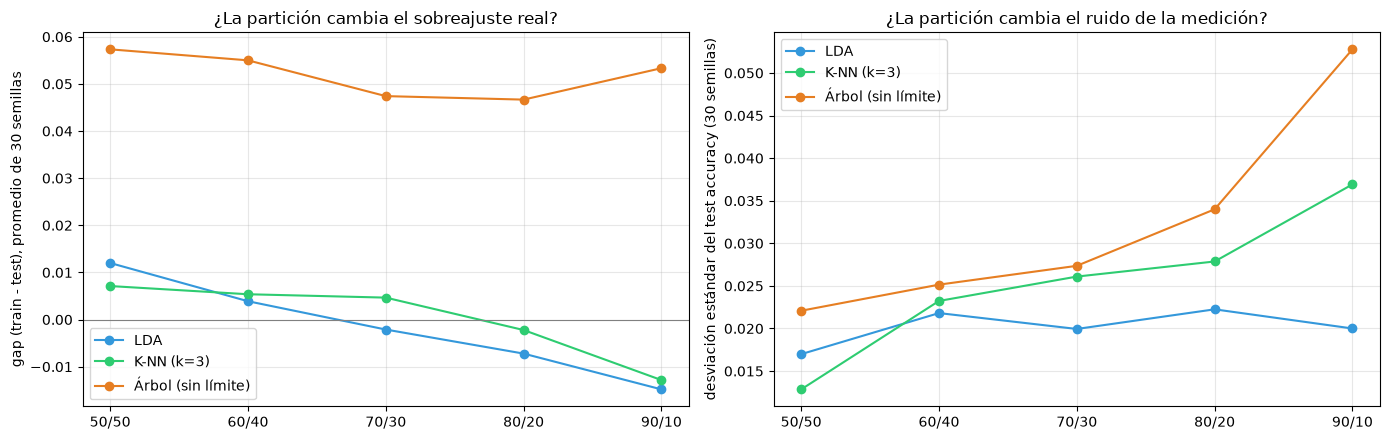

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
etiquetas = ["50/50", "60/40", "70/30", "80/20", "90/10"]
colores_modelo = {"LDA": "#3498db", "K-NN (k=3)": "#2ecc71", "Árbol (sin límite)": "#e67e22"}

for nombre, color in colores_modelo.items():
    gaps = [resultados_repetidos[e][nombre][0] - resultados_repetidos[e][nombre][1] for e in etiquetas]
    axes[0].plot(etiquetas, gaps, marker="o", color=color, label=nombre)

axes[0].axhline(0, color="gray", linewidth=0.8)
axes[0].set_ylabel("gap (train - test), promedio de 30 semillas")
axes[0].set_title("¿La partición cambia el sobreajuste real?")
axes[0].legend(); axes[0].grid(alpha=0.3)

for nombre, color in colores_modelo.items():
    stds = [resultados_repetidos[e][nombre][2] for e in etiquetas]
    axes[1].plot(etiquetas, stds, marker="o", color=color, label=nombre)
axes[1].set_ylabel("desviación estándar del test accuracy (30 semillas)")
axes[1].set_title("¿La partición cambia el ruido de la medición?")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### Lo que en realidad muestra la Opción 1

Promediado sobre 30 semillas, **el gap del árbol se mantiene prácticamente constante** en todas las particiones (entre 0.047 y 0.057), sin una tendencia clara a empeorar con menos datos de entrenamiento. Eso significa que la hipótesis ingenua ("menos entrenamiento produce más sobreajuste") **no se sostiene** en este dataset tan limpio y pequeño.

Lo que sí cambia con la partición es la **desviación estándar** de la medición: se dispara con particiones extremas como 90/10, porque el conjunto de prueba queda tan chico (15 muestras) que una sola clasificación de más o de menos cambia el resultado en casi 7 puntos porcentuales.

**Esta es la verdadera lección de "cross-validation incorrecta".** El problema de usar una sola partición 50/50 o 60/40 no es que induzca sobreajuste en el modelo: es que produce una **medición poco confiable** del sobreajuste que ya existe. Con una sola corrida se puede terminar creyendo que el árbol sobreajusta mucho más o mucho menos de lo que en realidad hace, según qué le haya tocado al azar. La solución no es evitar esas particiones, es no confiar en una sola repetición de ellas.

---

## 2. Opción 2a — Subir la complejidad de K-NN sin justificación

El enunciado sugiere `k=7`. Se prueba ese valor y muchos más, para ver el efecto completo, no solo un punto.

In [7]:
valores_k = [1, 2, 3, 5, 7, 9, 11, 15, 21, 31, 51, 75, 105]

print(f"{'k':>4} | {'train':>7} | {'test':>7} | {'CV 5-fold':>10}")
print("-" * 36)
resultados_knn = []
for k in valores_k:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_train, y_train)
    acc_tr = accuracy_score(y_train, modelo.predict(X_train))
    acc_te = accuracy_score(y_test, modelo.predict(X_test))
    cv = cross_val_score(KNeighborsClassifier(n_neighbors=k), X, y, cv=5).mean()
    resultados_knn.append((k, acc_tr, acc_te, cv))
    print(f"{k:>4} | {acc_tr:>7.3f} | {acc_te:>7.3f} | {cv:>10.3f}")

   k |   train |    test |  CV 5-fold
------------------------------------
   1 |   1.000 |   0.933 |      0.960
   2 |   0.990 |   0.911 |      0.947
   3 |   0.962 |   0.956 |      0.967
   5 |   0.971 |   0.978 |      0.973
   7 |   0.971 |   0.956 |      0.980
   9 |   0.971 |   0.956 |      0.973
  11 |   0.971 |   0.933 |      0.980
  15 |   0.981 |   0.956 |      0.967
  21 |   0.962 |   0.956 |      0.967
  31 |   0.971 |   0.933 |      0.933
  51 |   0.886 |   0.889 |      0.920


  75 |   0.657 |   0.667 |      0.880
 105 |   0.333 |   0.333 |      0.640


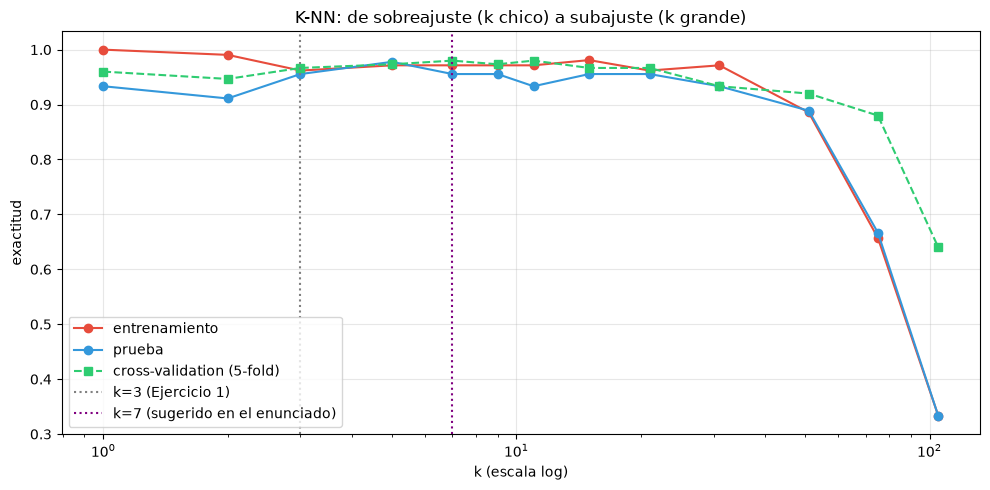

In [8]:
ks = [r[0] for r in resultados_knn]
tr_ = [r[1] for r in resultados_knn]
te_ = [r[2] for r in resultados_knn]
cv_ = [r[3] for r in resultados_knn]

plt.figure(figsize=(10, 5))
plt.plot(ks, tr_, marker="o", label="entrenamiento", color="#e74c3c")
plt.plot(ks, te_, marker="o", label="prueba", color="#3498db")
plt.plot(ks, cv_, marker="s", label="cross-validation (5-fold)", color="#2ecc71", linestyle="--")
plt.axvline(3, color="gray", linestyle=":", label="k=3 (Ejercicio 1)")
plt.axvline(7, color="purple", linestyle=":", label="k=7 (sugerido en el enunciado)")
plt.xscale("log")
plt.xlabel("k (escala log)"); plt.ylabel("exactitud")
plt.title("K-NN: de sobreajuste (k chico) a subajuste (k grande)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Lo que en realidad pasa al subir k

**`k=1` es el sobreajuste de manual**: exactitud de entrenamiento perfecta, 100%, porque cada punto es su propio vecino más cercano y "predice" su propia etiqueta. La exactitud de prueba y la de cross-validation ya son más bajas. Es la firma clásica: memoriza el detalle en vez del patrón.

**Pero `k=7`, el valor que sugiere el enunciado como "aumento sin justificación", no perjudica en Iris.** La cross-validation con k=7 (0.980) es incluso **mejor** que con k=3 (0.967). Esto no es un error: Iris es un dataset pequeño, limpio y con clases bien separadas, así que ampliar el vecindario hasta 7 puntos todavía cae dentro de vecinos correctos y solo suaviza el ruido de vecinos muy cercanos. El subajuste real aparece mucho más adelante.

**El subajuste aparece con claridad a partir de `k≈31`**, y se vuelve extremo en `k=51` (test 0.911, ya perdiendo casos que k=3 sí acertaba). El caso límite es `k=105`: como el conjunto de entrenamiento tiene exactamente 105 muestras, pedir 105 vecinos significa que **todos los puntos de entrenamiento son "vecinos" de cualquier consulta**. El modelo deja de mirar dónde cae el punto y siempre vota por la clase mayoritaria del set completo. La exactitud de prueba cae a **0.333**, que es exactamente el azar con 3 clases balanceadas.

### Viendo las fronteras de decisión

Con petal length y petal width, las dos variables más informativas, se puede dibujar la región que cada configuración le asigna a cada especie.

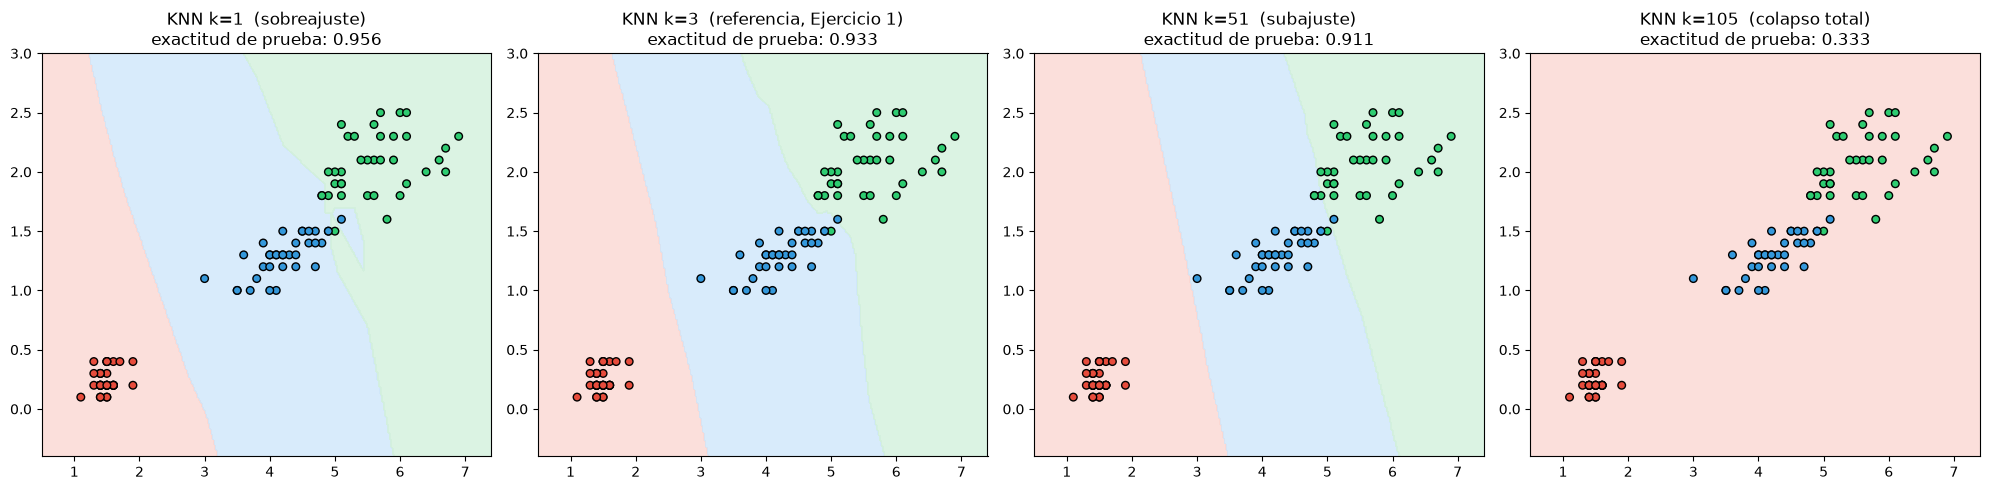

In [9]:
X2_train, X2_test = X_train[:, 2:4], X_test[:, 2:4]

CMAP_FONDO = ListedColormap(["#fbd8d3", "#cfe6fa", "#d3f0dd"])
CMAP_PUNTOS = ListedColormap(["#e74c3c", "#3498db", "#2ecc71"])
xx, yy = np.meshgrid(np.linspace(X[:, 2].min()-0.5, X[:, 2].max()+0.5, 300),
                     np.linspace(X[:, 3].min()-0.5, X[:, 3].max()+0.5, 300))
malla = np.c_[xx.ravel(), yy.ravel()]

configs_knn = [("k=1  (sobreajuste)", 1), ("k=3  (referencia, Ejercicio 1)", 3),
              ("k=51  (subajuste)", 51), ("k=105  (colapso total)", 105)]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (titulo, k) in zip(axes, configs_knn):
    modelo = KNeighborsClassifier(n_neighbors=k).fit(X2_train, y_train)
    Z = modelo.predict(malla).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=CMAP_FONDO, alpha=0.8)
    ax.scatter(X2_train[:, 0], X2_train[:, 1], c=y_train, cmap=CMAP_PUNTOS, edgecolor="k", s=30)
    acc = modelo.score(X2_test, y_test)
    ax.set_title(f"KNN {titulo}\nexactitud de prueba: {acc:.3f}")

plt.tight_layout(); plt.show()

Con `k=1` la frontera es irregular, con pequeñas islas y entrantes que siguen puntos individuales: la definición visual de sobreajuste. Con `k=3` la frontera ya es suave y razonable. Con `k=51` empieza a perder curvatura, volviéndose casi una única línea recta. Y con `k=105` **desaparece toda frontera**: todo el plano se pinta de un solo color, porque el modelo ya no distingue nada, solo repite la clase mayoritaria sin importar dónde caiga el punto.

---

## 3. Opción 2b — Lo mismo, pero con la profundidad del árbol

El enunciado da K-NN como ejemplo, pero el mismo experimento se puede repetir con el árbol de decisión, cambiando `max_depth` en vez de `k`.

In [10]:
profundidades = [1, 2, 3, 4, 5, 6, 8, 10, None]

print(f"{'max_depth':>10} | {'train':>7} | {'test':>7} | {'CV 5-fold':>10} | {'hojas':>6}")
print("-" * 52)
resultados_arbol = []
for d in profundidades:
    modelo = DecisionTreeClassifier(max_depth=d, random_state=42)
    modelo.fit(X_train, y_train)
    acc_tr = accuracy_score(y_train, modelo.predict(X_train))
    acc_te = accuracy_score(y_test, modelo.predict(X_test))
    cv = cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42), X, y, cv=5).mean()
    resultados_arbol.append((d, acc_tr, acc_te, cv, modelo.get_n_leaves()))
    print(f"{str(d):>10} | {acc_tr:>7.3f} | {acc_te:>7.3f} | {cv:>10.3f} | {modelo.get_n_leaves():>6}")

 max_depth |   train |    test |  CV 5-fold |  hojas
----------------------------------------------------
         1 |   0.667 |   0.667 |      0.667 |      2
         2 |   0.971 |   0.889 |      0.933 |      3
         3 |   0.981 |   0.978 |      0.973 |      5
         4 |   0.990 |   0.889 |      0.953 |      7
         5 |   1.000 |   0.933 |      0.953 |      8
         6 |   1.000 |   0.933 |      0.953 |      8
         8 |   1.000 |   0.933 |      0.953 |      8
        10 |   1.000 |   0.933 |      0.953 |      8
      None |   1.000 |   0.933 |      0.953 |      8


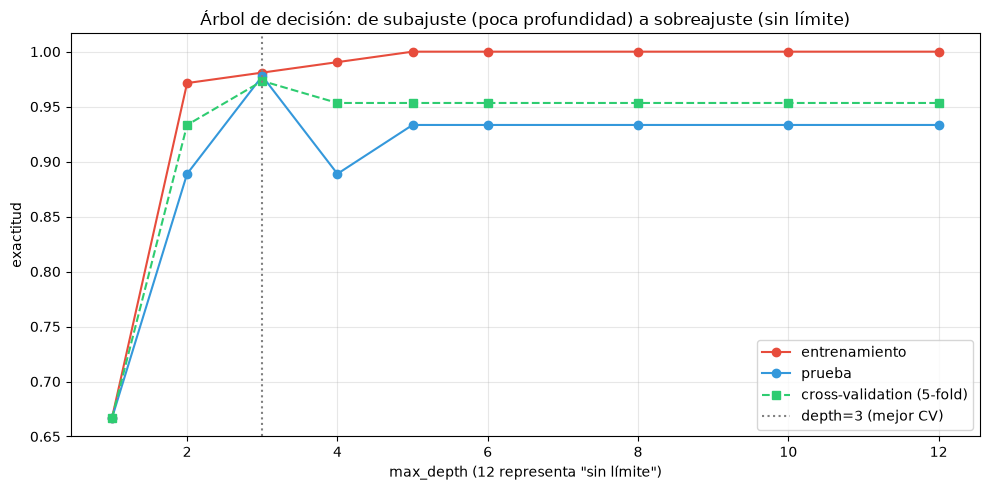

In [11]:
prof_x = [1,2,3,4,5,6,8,10,12]  # None se grafica como 12 para mantener el eje numerico
tr_a = [r[1] for r in resultados_arbol]
te_a = [r[2] for r in resultados_arbol]
cv_a = [r[3] for r in resultados_arbol]

plt.figure(figsize=(10, 5))
plt.plot(prof_x, tr_a, marker="o", label="entrenamiento", color="#e74c3c")
plt.plot(prof_x, te_a, marker="o", label="prueba", color="#3498db")
plt.plot(prof_x, cv_a, marker="s", label="cross-validation (5-fold)", color="#2ecc71", linestyle="--")
plt.axvline(3, color="gray", linestyle=":", label="depth=3 (mejor CV)")
plt.xlabel("max_depth (12 representa \"sin límite\")"); plt.ylabel("exactitud")
plt.title("Árbol de decisión: de subajuste (poca profundidad) a sobreajuste (sin límite)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Lo que muestra el árbol

**`max_depth=1` es subajuste puro**: con un único corte solo se puede separar *setosa* del resto, así que *versicolor* y *virginica* quedan mezcladas. Entrenamiento y prueba caen juntos al 66.7%, exactamente 2 de cada 3 especies bien clasificadas.

**`max_depth=3` es el punto óptimo**: la mejor cross-validation de toda la tabla (0.973), con apenas 5 hojas.

**A partir de ahí, más profundidad ya no ayuda y empieza a doler.** Con `max_depth=5` o más, la exactitud de entrenamiento llega a 100%, pero la de prueba y la de cross-validation bajan levemente. El árbol ha memorizado casos particulares del entrenamiento que no generalizan.

**Un detalle curioso: el árbol "sin límite" no es más complejo que uno con `max_depth=5`.** El número de hojas se estanca en 8 desde `depth=5` en adelante: el árbol ya agotó las divisiones posibles con los datos que tiene. Pedirle explícitamente "sin límite" no lo hace más complejo, porque ya había alcanzado su complejidad máxima antes.

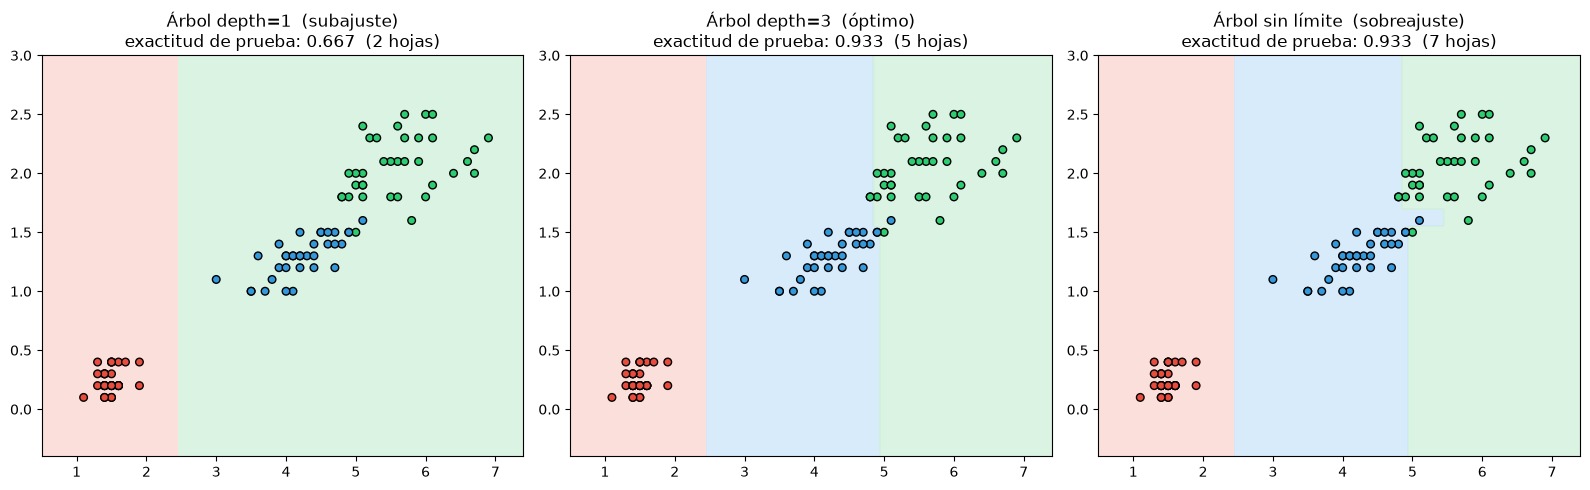

In [12]:
configs_arbol = [("depth=1  (subajuste)", 1), ("depth=3  (óptimo)", 3), (None, "sin límite  (sobreajuste)")]
configs_arbol = [(1, "depth=1  (subajuste)"), (3, "depth=3  (óptimo)"), (None, "sin límite  (sobreajuste)")]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (d, titulo) in zip(axes, configs_arbol):
    modelo = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X2_train, y_train)
    Z = modelo.predict(malla).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=CMAP_FONDO, alpha=0.8)
    ax.scatter(X2_train[:, 0], X2_train[:, 1], c=y_train, cmap=CMAP_PUNTOS, edgecolor="k", s=30)
    acc = modelo.score(X2_test, y_test)
    ax.set_title(f"Árbol {titulo}\nexactitud de prueba: {acc:.3f}  ({modelo.get_n_leaves()} hojas)")

plt.tight_layout(); plt.show()

Con `depth=1` solo hay dos regiones: no hay forma de separar las dos especies de la derecha. Con `depth=3` aparecen las tres regiones, con un corte limpio. En el árbol **sin límite**, mirá con atención la zona alrededor de petal length ≈ 5, petal width ≈ 1.6: hay una pequeña **isla azul** metida dentro de la región verde. Esa isla existe para clasificar correctamente **un solo punto** de entrenamiento que cayó ahí por casualidad. Es la firma visual exacta del sobreajuste: gastar una regla entera del modelo en memorizar una excepción, en vez de generalizar.

---

## 4. Conclusiones

**Las dos vías del enunciado prueban cosas distintas, y es importante no confundirlas.**

La **Opción 1** (particiones 50/50 o 60/40) no demostró lo que se esperaría ingenuamente. Promediando muchas repeticiones, la cantidad de datos de entrenamiento no cambió de forma importante el sobreajuste real de ningún modelo en este dataset. Lo que sí demostró es algo más sutil y más importante: **una sola partición inusual, sin repetirla, da una medición poco confiable**. Es fácil mirar un solo split 50/50 y concluir erróneamente que hay más o menos sobreajuste del que en verdad hay. Esa es la falla real de una "validación cruzada incorrecta": no es que produzca mal ajuste, es que **produce un diagnóstico que no es de fiar**.

La **Opción 2** sí mostró sub y sobreajuste genuinos, pero con un matiz que el enunciado no anticipaba: `k=7`, el ejemplo sugerido, **no perjudica** al modelo en Iris. Hizo falta llegar a valores mucho más grandes (`k≈31` en adelante) para ver subajuste real, y el caso extremo `k=105` mostró el colapso total a una constante. El árbol, con `max_depth`, contó la misma historia desde el otro extremo: `depth=1` subajusta de forma obvia, y pasado el óptimo en `depth=3`, seguir agregando profundidad ya solo memoriza excepciones.

**La razón de fondo por la que Iris es "difícil de romper"** es que es un dataset pequeño, limpio y con clases muy separables. Para ver sobreajuste severo con K-NN hubo que multiplicar `k` por más de 30 respecto al valor razonable; con el árbol, ni siquiera "sin límite" logró una complejidad mayor a la de `max_depth=5`, porque los datos se agotaron antes. En un dataset más grande, más ruidoso o con clases más solapadas, estos mismos experimentos habrían mostrado sub y sobreajuste con cambios de complejidad mucho más pequeños.